# 2~3주차 통합 실습 — 토큰에서 Transformer까지


In [ ]:
%pip -q install "transformers==4.57.6" "numpy>=1.26,<2.3" "pandas>=2.2,<3" "matplotlib>=3.8,<3.11"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 122.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


설치 후 import 오류가 나면 커널/런타임을 재시작하고 다음 셀부터 실행한다. PyTorch는 Colab의 기본 설치를 사용한다. 로컬 환경에는 PyTorch가 별도로 필요하다. 이번 실습에서 사용하지 않는 PEFT·Accelerate는 설치하지 않는다.


In [ ]:
import os, sys, json, math, random, hashlib, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from transformers import AutoTokenizer

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
# 작은 행렬 관찰 실습이므로 CPU로 통일
DEVICE = torch.device("cpu")
torch.set_num_threads(min(4, os.cpu_count() or 1))
STUDENT_ID = ""  # TODO
STUDENT_NAME = ""  # TODO
RESULT_DIR = Path("lab_results_week23")
RESULT_DIR.mkdir(exist_ok=True)
ENV = {"python": sys.version.split()[0], "torch": torch.__version__,
       "device": str(DEVICE), "seed": SEED}
PASSED = set()
def passed(key):
    PASSED.add(key)
    print(f"{key}: 수치 검사 통과")
def save_json(name, obj):
    (RESULT_DIR/name).write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
def heatmap(matrix, title, labels=None, vmax=1):
    matrix = matrix.detach().cpu()
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(matrix, vmin=0, vmax=vmax, cmap="Blues")
    if labels is not None:
        ax.set_xticks(range(len(labels)), labels=labels)
        ax.set_yticks(range(len(labels)), labels=labels)
    ax.set(xlabel="Key position", ylabel="Query position", title=title)
    fig.colorbar(im, ax=ax); plt.show()
display(pd.DataFrame([ENV]))


,python,torch,device,seed
0,3.13.15,2.11.0+cu128,cpu,42


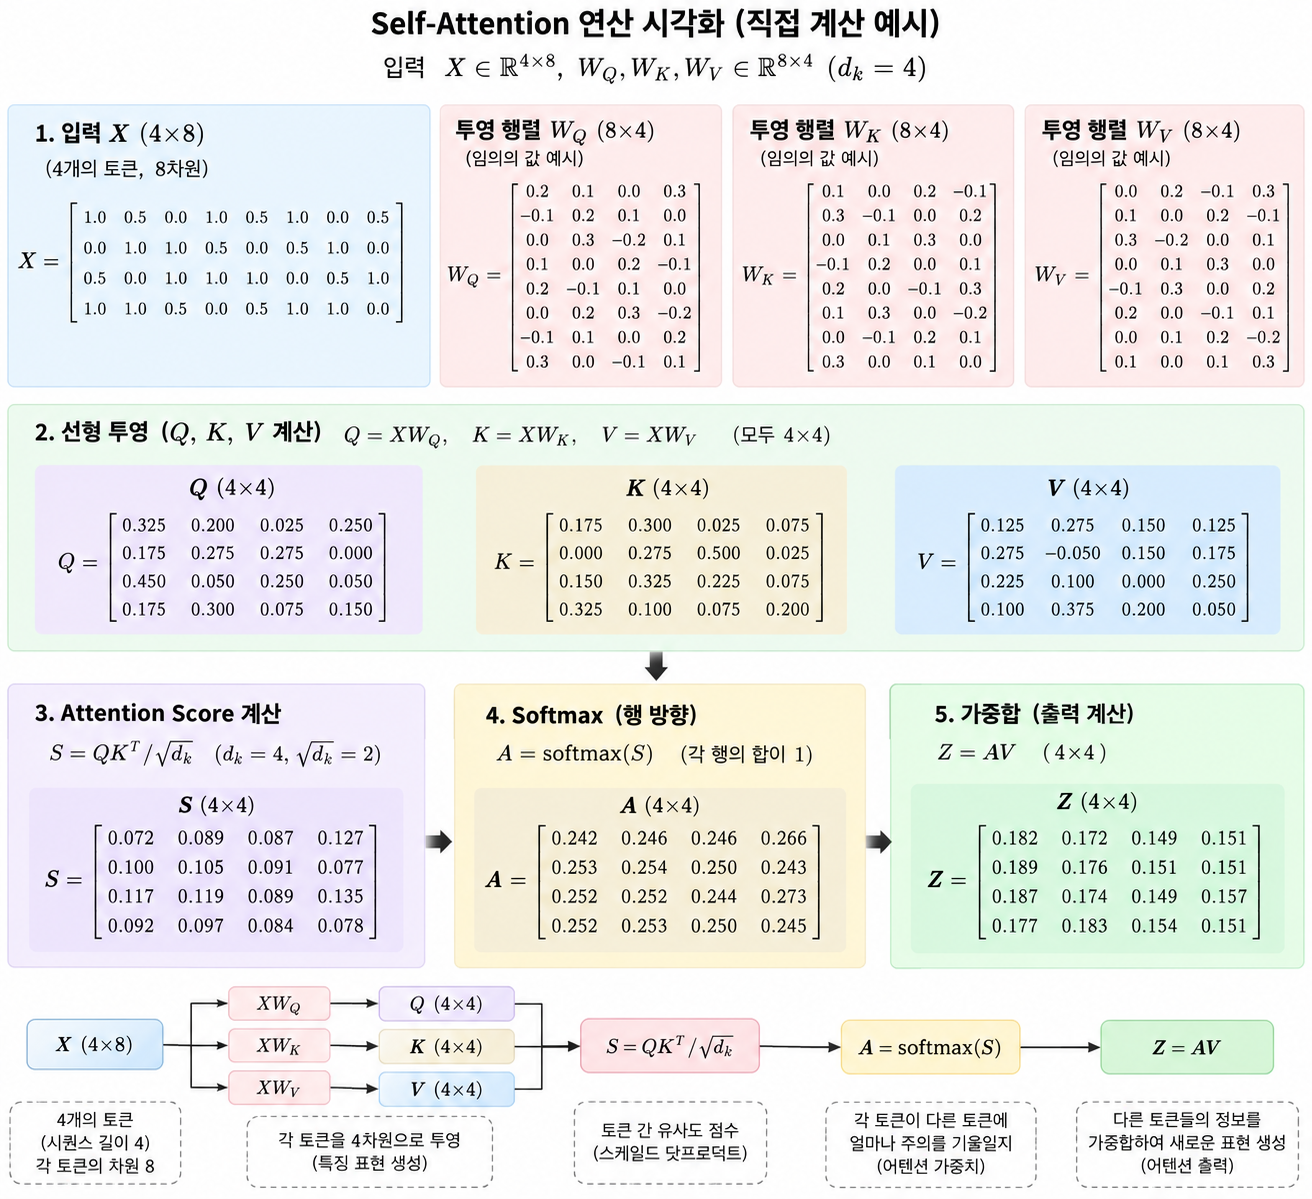

## 과제. Attention을 직접 완성하라
입력 $X\in\mathbb{R}^{4\times8}$, 투영행렬 $W_Q,W_K,W_V\in\mathbb{R}^{8\times4}$이다.

$$Q=XW_Q,\quad K=XW_K,\quad V=XW_V,$$
$$S=QK^T/\sqrt{d_k},\quad A=\mathrm{softmax}(S),\quad Z=AV.$$



In [ ]:
words = ["student", "reads", "a", "book"]
vocab = {word:i for i,word in enumerate(words)}
torch.manual_seed(SEED)
embedding = nn.Embedding(len(vocab), 8)
X = embedding(torch.arange(len(words))).detach()
torch.manual_seed(7)
WQ, WK, WV = [torch.randn(8,4)/math.sqrt(8) for _ in range(3)]
display(pd.DataFrame(X.numpy(), index=words))


,0,1,2,3,4,5,6,7
student,1.926915,1.487284,0.900717,-2.105521,0.678418,-1.234545,-0.043067,-1.604667
reads,-0.752135,1.648723,-0.392479,-1.403607,-0.727881,-0.559430,-0.768839,0.762445
a,1.642317,-0.159597,-0.497398,0.439589,-0.758131,1.078318,0.800801,1.680621
book,1.279124,1.296423,0.610466,1.334738,-0.231624,0.041759,-0.251575,0.859859


In [ ]:
def my_attention(x, wq, wk, wv):
    Q = None  # TODO
    K = None  # TODO
    V = None  # TODO
    assert all(t is not None for t in (Q,K,V)), "Q, K, V를 구현하세요."
    scores = None  # TODO: sqrt(d_k)로 나눈 점수
    assert scores is not None, "scores를 구현하세요."
    A = None  # TODO: 각 query의 key 가중치 합이 1이 되도록
    assert A is not None, "A를 구현하세요."
    Z = None  # TODO
    assert Z is not None, "Z를 구현하세요."
    return Q, K, V, scores, A, Z

Q,K,V,scores,A,Z = my_attention(X,WQ,WK,WV)
assert Q.shape == K.shape == V.shape == (4,4)
assert A.shape == Z.shape == (4,4)
assert torch.allclose(A.sum(-1), torch.ones(4), atol=1e-6)
# 구현이 입력 변화에 반응하고 일반적인 길이에도 동작하는지 확인
probe = torch.randn(5,8)
pq,pk,pv,ps,pa,pz = my_attention(probe,WQ,WK,WV)
assert torch.allclose(pq, probe @ WQ)
assert torch.allclose(pk, probe @ WK) and torch.allclose(pv, probe @ WV)
assert torch.allclose(ps, pq @ pk.T / math.sqrt(pq.shape[-1]))
assert torch.allclose(pa, ps.softmax(-1)) and torch.allclose(pz, pa @ pv)
heatmap(A, "Unmasked attention", words)
passed("task2_attention")


In [ ]:
QUERY_INDEX = None  # TODO: 0~3에서 선택
assert QUERY_INDEX in range(4), "query 위치를 선택하세요."
parts = None  # TODO: 각 key의 기여도. shape (4,4), A의 선택한 행과 V 사용
assert parts is not None, "가중합의 개별 항을 구현하세요."
assert parts.shape == (4,4)
assert torch.allclose(parts, A[QUERY_INDEX,:,None]*V, atol=1e-6)
assert torch.allclose(parts.sum(0), Z[QUERY_INDEX], atol=1e-6)
display(pd.DataFrame(parts.numpy(), index=words, columns=[f"feature{i}" for i in range(4)]))
print("attention weights:", A[QUERY_INDEX].tolist())
print("output:", Z[QUERY_INDEX].tolist())
passed("task2_sum")


## Layer Normalization 이해
Transformer/GPT 블록에서 LayerNorm이 어디에 위치하는지에 따라 학습 안정성과 warm-up 필요성이 달라짐.

추천 영상:youtube.com/watch?si=hdgME7m8OStMzu0M&v=gyBGvqQEeNI&feature=youtu.be

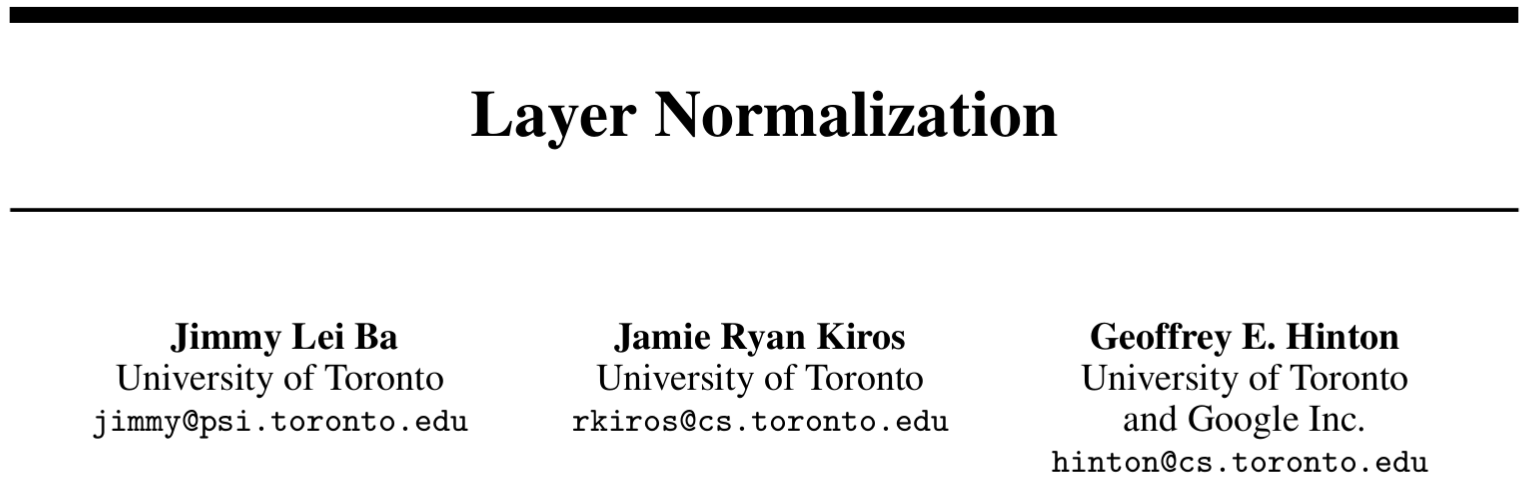

https://theaisummer.com/normalization/

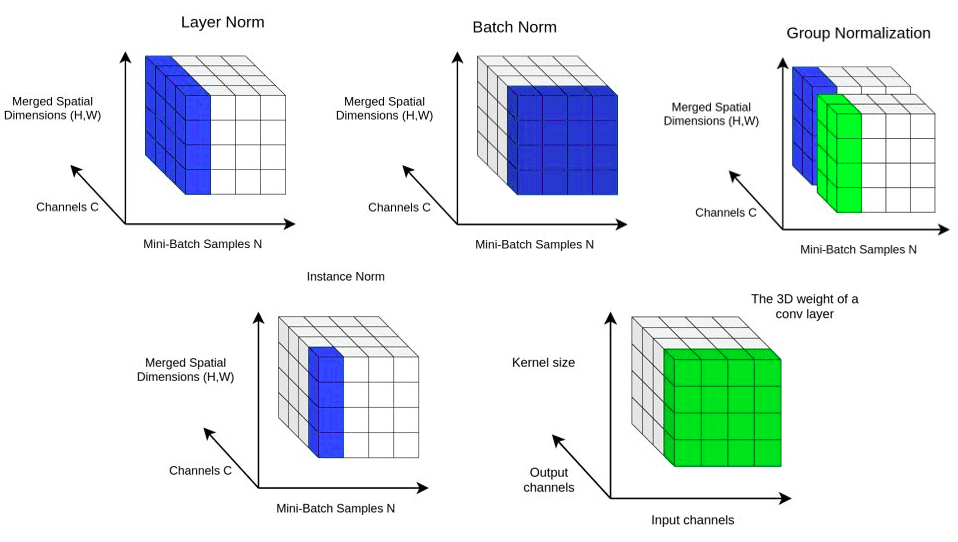

## Causal mask

##실제로 mask를 하지 않는 경우 정답지를 보고 학습하는가?


##과제 2. 궁금증을 해결하기 위해 어떤 실험을 설계할 수 있을까?

## FFN — 왜 넓혔다 줄일까?

Transformer FFN은 각 토큰의 벡터에 독립적으로 적용된다.
$$\operatorname{FFN}(x)=W_2\sigma(W_1x+b_1)+b_2.$$
중간 폭을 늘리면 더 많은 비선형 특징을 계산할 수 있고, 출력은 다음 블록과 잔차 연결에 맞도록 원래 차원으로 돌아온다. **차원 확장이 새 입력 정보를 만드는 것은 아니다.**

활성화가 없으면
$$W_2(W_1x+b_1)+b_2=(W_2W_1)x+(W_2b_1+b_2)$$
이므로 넓혀도 하나의 affine 변환에 불과하다.

먼저 $y=x^2$를 근사해 이를 눈으로 확인한다. 1차원 입출력은 시각화를 위한 것으로, 실제 토큰 FFN에서는 $d\rightarrow d_{ff}\rightarrow d$가 된다.

| 모델 | 확인할 내용 |
|---|---|
| 1 → 32 → 1, 활성화 없음 | 넓히기만 하면 곡선을 표현할까? |
| 1 → 4 → 1, GELU | 비선형 함수를 넣으면? |
| 1 → 32 → 1, GELU | 비선형 특징의 개수를 늘리면? |

VAE는 재구성과 KL 정규화로 확률적 latent를 학습하는 모델이다. 흔히 latent를 작게 두지만, FFN의 중간 특징 변환과 목적이 다르다. VAE가 반드시 입력보다 낮은 차원의 latent를 가져야 하는 것도 아니다.


In [ ]:
# 실제 Transformer에도 그대로 사용할 수 있는 FFN 부품
class FFN(nn.Module):
    def __init__(self,d,hidden,nonlinear=True):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,hidden),
                               nn.GELU() if nonlinear else nn.Identity(),
                               nn.Linear(hidden,d))
    def forward(self,x):
        return self.net(x)

# FFN 비교는 아주 작아 CPU로 실행
x_train=torch.linspace(-1,1,80)[:,None]
y_train=x_train.square()
x_test=torch.linspace(-1,1,401)[:,None]
y_test=x_test.square()
settings={"Linear, width 32":(32,False),"GELU, width 4":(4,True),"GELU, width 32":(32,True)}
FFN_STEPS=1500
ffn_results=[]
curves={}; fitted={}
# 폭에 따른 차이를 하나의 운 좋은 초기화로 단정하지 않도록 3개 seed 비교
for name,(width,nonlinear) in settings.items():
    for seed in [0,1,2]:
        torch.manual_seed(seed)
        net=FFN(1,width,nonlinear)
        opt=torch.optim.Adam(net.parameters(),lr=0.01)
        losses=[]
        for step in range(FFN_STEPS):
            opt.zero_grad(set_to_none=True)
            loss=F.mse_loss(net(x_train),y_train)
            loss.backward(); opt.step()
            losses.append(loss.item())
        with torch.no_grad():
            mse=F.mse_loss(net(x_test),y_test).item()
        ffn_results.append({"model":name,"seed":seed,"test_mse":mse,
                            "parameters":sum(p.numel() for p in net.parameters())})
        if seed==0: curves[name]=losses; fitted[name]=net.eval()
print("완료")


완료


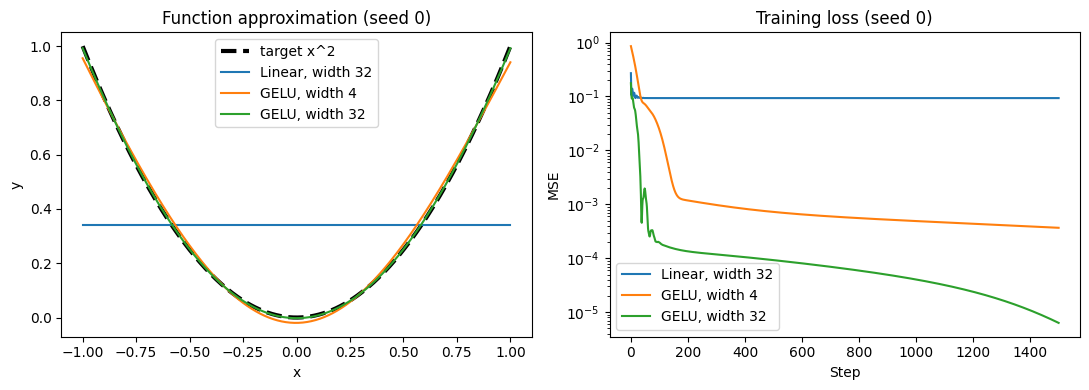

,parameters,mse_mean,mse_std
model,,,
"GELU, width 32",97,0.000024,3.340541e-05
"GELU, width 4",13,0.030056,5.176133e-02
"Linear, width 32",97,0.089824,4.301595e-09


In [ ]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(x_test[:,0],y_test[:,0],"k--",label="target x^2",lw=3)
with torch.no_grad():
    for name,net in fitted.items():
        axes[0].plot(x_test[:,0],net(x_test)[:,0],label=name)
        axes[1].semilogy(curves[name],label=name)
axes[0].set(title="Function approximation (seed 0)",xlabel="x",ylabel="y")
axes[1].set(title="Training loss (seed 0)",xlabel="Step",ylabel="MSE")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()
ffn_table=pd.DataFrame(ffn_results)
display(ffn_table.groupby("model").agg(parameters=("parameters","first"),
                                      mse_mean=("test_mse","mean"),mse_std=("test_mse","std")))


## 작은 언어모델 학습 실습

**데이터 → 토큰 ID → 작은 GPT → 다음 토큰 예측 → 문장 생성**

[TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories)는 짧고 쉬운 영어 이야기 데이터다. 전체 대신 학습용 10,000개, 검증용 500개만 불러온다.

모델은 [GPT2Config와 GPT2LMHeadModel](https://huggingface.co/docs/transformers/v4.57.1/en/model_doc/gpt2)로 만든 **4층·hidden 256의 약 1,600만 파라미터 GPT**다. 기존 토크나이저만 사용하고, **임베딩을 포함한 모델 가중치는 모두 무작위 초기화**한다. 위에서 작성한 `my_attention` 함수를 직접 연결하는 대신, 같은 attention 원리를 구현한 라이브러리 모델을 사용한다.

이 짧은 학습의 목표는 loss 감소와 생성 패턴 변화를 관찰하는 것이다. 완성도 높은 이야기나 질문에 답하는 챗봇을 기대하는 실습은 아니다.


### 1. 데이터셋 불러오기
Streaming으로 필요한 개수만 읽는다. 최초 실행에는 인터넷 연결이 필요하며, 다운로드와 토큰화 시간은 학습시간과 별도다.


In [ ]:
from datasets import load_dataset
from transformers import GPT2Config, GPT2LMHeadModel, AutoTokenizer
import time
from contextlib import nullcontext

TRAIN_STORIES = 10_000
VAL_STORIES = 500

train_stream = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
val_stream = load_dataset("roneneldan/TinyStories", split="validation", streaming=True)
train_texts = [row["text"] for row in train_stream.take(TRAIN_STORIES)]
val_texts = [row["text"] for row in val_stream.take(VAL_STORIES)]
print("학습 이야기:", len(train_texts), "검증 이야기:", len(val_texts))
print("\n예시 이야기:\n", train_texts[0])


README.md: 0.00B [00:00, ?B/s]

학습 이야기: 10000 검증 이야기: 500

예시 이야기:
 One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


### 2. 토큰화와 학습 입력 만들기
이야기 사이에 EOS(문서 끝) 토큰을 넣고 이어 붙인다. 길이 128인 구간을 뽑아 학습한다. 문서 경계에서 attention을 별도로 차단하지 않는 간단한 packing 방식이다.

`labels=input_ids`로 전달하면 GPT 모델 내부에서 정답을 한 칸 이동한다. **직접 labels를 또 이동하지 않는다.** 예를 들어 입력 `[Once, upon, a, time]`에서 앞의 세 위치가 각각 `[upon, a, time]`을 예측한다.


In [ ]:
lm_tok = AutoTokenizer.from_pretrained(
    "distilbert/distilgpt2", revision="2290a62682d06624634c1f46a6ad5be0f47f38aa")
lm_tok.pad_token = lm_tok.eos_token
CONTEXT = 128
BATCH_SIZE = 8  # RTX 3070 8GB 시작 설정. 메모리 부족 시 4 또는 2.

# 한꺼번에 너무 많이 토큰화하지 않도록 256개 이야기씩 처리
# 모델 학습에 쓰는 길이는 아래 get_batch에서 128로 제한한다.
def encode_stories(texts):
    ids = []
    for i in range(0, len(texts), 256):
        encoded = lm_tok(texts[i:i+256], add_special_tokens=False,
                         truncation=False, verbose=False)["input_ids"]
        for story in encoded:
            ids.extend(story)
            ids.append(lm_tok.eos_token_id)
    return torch.tensor(ids, dtype=torch.long)

train_ids = encode_stories(train_texts)
val_ids = encode_stories(val_texts)
print(f"학습 {len(train_ids):,} tokens / 검증 {len(val_ids):,} tokens")
LM_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("학습 장치:", torch.cuda.get_device_name(0) if LM_DEVICE.type == "cuda" else "CPU (느림)")

def get_batch(ids, generator=None):
    starts = torch.randint(len(ids)-CONTEXT+1, (BATCH_SIZE,), generator=generator)
    return torch.stack([ids[i:i+CONTEXT] for i in starts.tolist()]).to(LM_DEVICE)

example = get_batch(train_ids)
print("입력 shape:", tuple(example.shape))
print("입력 앞부분:", lm_tok.decode(example[0,:30].tolist()))


학습 2,162,078 tokens / 검증 100,955 tokens
학습 장치: CPU (느림)
입력 shape: (8, 128)
입력 앞부분:  room full of amazing treasures! Annie smiled. Her troubles had gone away. From that day on, she visited the museum often, searching for more special


### 3. 작은 GPT 만들고 학습 전 문장 생성
`GPT2LMHeadModel(config)`는 구조만 이용해 새 모델을 만든다. 모델 가중치를 불러오는 `from_pretrained`를 사용하지 않는다.

이 셀을 다시 실행하면 모델이 초기화된다. 학습을 이어가려면 이 셀 대신 학습 셀만 다시 실행한다.


In [ ]:
torch.manual_seed(SEED)
config = GPT2Config(
    vocab_size=len(lm_tok), n_positions=CONTEXT, n_ctx=CONTEXT,
    n_embd=256, n_layer=4, n_head=4,
    resid_pdrop=0.0, embd_pdrop=0.0, attn_pdrop=0.0,
    bos_token_id=lm_tok.bos_token_id, eos_token_id=lm_tok.eos_token_id,
    pad_token_id=lm_tok.pad_token_id, use_cache=False,
)
model = GPT2LMHeadModel(config).to(LM_DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)
use_cuda = LM_DEVICE.type == "cuda"
amp_dtype = torch.bfloat16 if use_cuda and torch.cuda.is_bf16_supported() else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=use_cuda and amp_dtype == torch.float16)
def amp_context():
    return torch.autocast("cuda", dtype=amp_dtype) if use_cuda else nullcontext()

@torch.no_grad()
def generate_text(prompt, temperature=0.8, seed=123):
    if not prompt.strip():
        raise ValueError("영어 프롬프트를 입력하세요.")
    # 같은 seed로 학습 전후 생성 샘플 비교. 학습 RNG에는 영향 주지 않음.
    cuda_devices = [torch.cuda.current_device()] if use_cuda else []
    with torch.random.fork_rng(devices=cuda_devices):
        torch.manual_seed(seed)
        model.eval()
        inputs = lm_tok(prompt, return_tensors="pt", truncation=True,
                        max_length=CONTEXT-64).to(LM_DEVICE)
        with amp_context():
            out = model.generate(**inputs, max_new_tokens=64, do_sample=True,
                                 temperature=temperature, top_k=40,
                                 pad_token_id=lm_tok.eos_token_id, use_cache=True)
    return lm_tok.decode(out[0], skip_special_tokens=True)

@torch.no_grad()
def validation_loss():
    model.eval()
    gen = torch.Generator().manual_seed(2026)  # 매번 같은 검증 구간 10배치
    values = []
    for _ in range(10):
        batch = get_batch(val_ids, gen)
        with amp_context():
            loss = model(input_ids=batch, labels=batch).loss
        values.append(loss.item())
    return sum(values)/len(values)

PROMPT = "Once upon a time, there was a little robot"
before_text = generate_text(PROMPT)
before_loss = validation_loss()
history = [{"step": 0, "train_loss": float("nan"), "val_loss": before_loss}]
completed_steps = 0
print(f"파라미터: {sum(p.numel() for p in model.parameters()):,}")
print(f"학습 전 validation loss: {before_loss:.3f}")
print("학습 전 생성:\n", before_text)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


파라미터: 16,058,112
학습 전 validation loss: 10.855
학습 전 생성:
 Once upon a time, there was a little robot invention whiskFootnote84 Neutral PSU人 HeathBO exempted exempted Kids BowmancandPokémon progressing doubt Rockefelleretsk Guide weddeters Temp TempoilerCN quitting fret fretITE unless particularGCanswerdirected heightenedselmile symbrr kinetic kinetic warn grounds plentiful 339 limb aliens Dup prosper Waterloo GPS internal FO toug comr HardgrenFormFormdanger rust routers Plug


### 4. 학습하기
기본 1,000 step은 약 102만 입력 토큰을 처리하는 짧은 실험이다. GPU별 시간은 **50 step마다 출력되는 실측 남은 시간**으로 확인한다. 처음에는 `STEPS=200`으로 줄여 동작을 확인해도 된다.

$$\mathcal{L}=-\frac{1}{B(T-1)}\sum_{b=1}^{B}\sum_{t=1}^{T-1}\log p_\theta(x_{b,t+1}\mid x_{b,\le t})$$

학습 셀을 다시 실행하면 현재 모델과 optimizer에서 추가 학습한다. 학습 전후를 새로 비교하려면 위의 모델 생성 셀부터 다시 실행한다.


In [ ]:
STEPS = 1000
LOG_EVERY = 50
assert STEPS >= 1

def synchronize():
    if use_cuda:
        torch.cuda.synchronize()

train_rng = torch.Generator().manual_seed(SEED + completed_steps)
step_times, recent_losses = [], []
start_step = completed_steps
for local_step in range(1, STEPS+1):
    model.train()
    synchronize()
    started = time.perf_counter()
    batch = get_batch(train_ids, train_rng)
    optimizer.zero_grad(set_to_none=True)
    with amp_context():
        loss = model(input_ids=batch, labels=batch).loss
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()
    synchronize()
    duration = time.perf_counter()-started
    if local_step > 10:  # 초기 warm-up 제외
        step_times.append(duration)
    recent_losses.append(loss.item())
    completed_steps = start_step + local_step
    if local_step % LOG_EVERY == 0 or local_step == STEPS:
        val_loss = validation_loss()
        train_loss = float(np.mean(recent_losses))
        history.append({"step": completed_steps, "train_loss": train_loss, "val_loss": val_loss})
        seconds = float(np.mean(step_times[-100:])) if step_times else duration
        eta = (STEPS-local_step)*seconds/60
        print(f"step {completed_steps:4d} | train {train_loss:.3f} | val {val_loss:.3f}"
              f" | {seconds:.3f} s/step | 남은 학습 약 {eta:.1f}분", flush=True)
        recent_losses.clear()
print("완료. 예상 시간은 검증·다운로드 시간을 제외한 학습 계산 기준입니다.")


step   50 | train 7.271 | val 5.452 | 2.006 s/step | 남은 학습 약 31.8분
step  100 | train 5.138 | val 4.745 | 2.013 s/step | 남은 학습 약 30.2분
step  150 | train 4.634 | val 4.429 | 2.017 s/step | 남은 학습 약 28.6분
step  200 | train 4.421 | val 4.246 | 1.984 s/step | 남은 학습 약 26.5분
step  250 | train 4.302 | val 4.148 | 1.947 s/step | 남은 학습 약 24.3분
step  300 | train 4.209 | val 4.046 | 2.008 s/step | 남은 학습 약 23.4분
step  350 | train 4.069 | val 3.928 | 2.021 s/step | 남은 학습 약 21.9분
step  400 | train 3.940 | val 3.843 | 1.964 s/step | 남은 학습 약 19.6분
step  450 | train 3.890 | val 3.777 | 1.956 s/step | 남은 학습 약 17.9분
step  500 | train 3.790 | val 3.697 | 1.956 s/step | 남은 학습 약 16.3분
step  550 | train 3.776 | val 3.653 | 1.957 s/step | 남은 학습 약 14.7분
step  600 | train 3.675 | val 3.578 | 1.963 s/step | 남은 학습 약 13.1분
step  650 | train 3.617 | val 3.525 | 1.961 s/step | 남은 학습 약 11.4분
step  700 | train 3.603 | val 3.486 | 1.956 s/step | 남은 학습 약 9.8분
step  750 | train 3.542 | val 3.438 | 1.970 s/step | 남은 학습 약 8.

### 5. 학습 전후 비교하고 프롬프트 바꾸기
Loss 감소가 문장 생성 품질 향상과 항상 일치하지는 않는다. 짧게 학습하면 반복·문법 오류가 남을 수 있다.


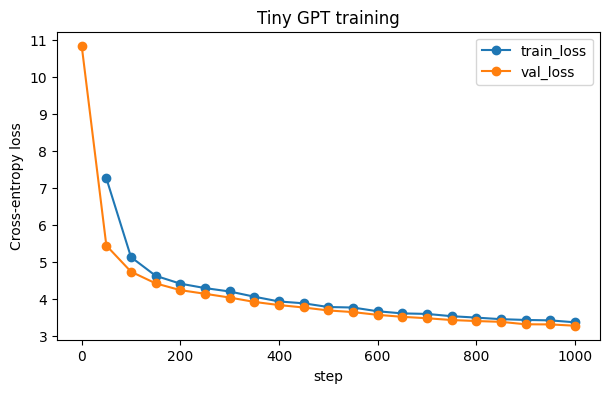

[같은 프롬프트] Once upon a time, there was a little robot

[학습 전]
 Once upon a time, there was a little robot invention whiskFootnote84 Neutral PSU人 HeathBO exempted exempted Kids BowmancandPokémon progressing doubt Rockefelleretsk Guide weddeters Temp TempoilerCN quitting fret fretITE unless particularGCanswerdirected heightenedselmile symbrr kinetic kinetic warn grounds plentiful 339 limb aliens Dup prosper Waterloo GPS internal FO toug comr HardgrenFormFormdanger rust routers Plug

[학습 후]
 Once upon a time, there was a little robot. The boy came over to play. He liked to play with his friends. One day, she saw a small ball in the ball. But it was so she saw a big, and said, "Oh the dog! I have to take it."

The boy was surprised, and his friends came to do

Validation loss: 10.855 → 3.284


In [ ]:
loss_table = pd.DataFrame(history)
ax = loss_table.plot(x="step", y=["train_loss", "val_loss"], figsize=(7,4), marker="o")
ax.set(ylabel="Cross-entropy loss", title="Tiny GPT training")
plt.show()
after_text = generate_text(PROMPT)
print("[같은 프롬프트]", PROMPT)
print("\n[학습 전]\n", before_text)
print("\n[학습 후]\n", after_text)
print(f"\nValidation loss: {before_loss:.3f} → {validation_loss():.3f}")


In [ ]:
# 이 두 값만 바꾸어 문장 생성 결과를 관찰한다.
MY_PROMPT = "One day, a little girl found a magic book"
TEMPERATURE = 0.8  # 비교 예: 0.5, 1.2 (0보다 커야 함)
assert TEMPERATURE > 0
print(generate_text(MY_PROMPT, temperature=TEMPERATURE))

One day, a little girl found a magic book. She wanted to make a small look at it. She saw a big, and looked on it. It was sad and asked, "Please, I do?"

But that was too late. The little girl had fallen up and the cat came back to the cat on her. She ran to her doll and
